### This dataset is designed for predicting food delivery times based on various influencing factors such as distance, weather, traffic conditions, and time of day. It offers a practical and engaging challenge for machine learning practitioners, especially those interested in logistics and operations research.

## Load the Library

In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load the dataset

In [89]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [90]:
df.head()       

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [91]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [92]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,500.500000,288.819436,1.00,250.750,500.50,750.2500,1000.00
Distance_km,1000.0,10.059970,5.696656,0.59,5.105,10.19,15.0175,19.99
Preparation_Time_min,1000.0,16.982000,7.204553,5.00,11.000,17.00,23.0000,29.00
Courier_Experience_yrs,970.0,4.579381,2.914394,0.00,2.000,5.00,7.0000,9.00
Delivery_Time_min,1000.0,56.732000,22.070915,8.00,41.000,55.50,71.0000,153.00


### Data Preprocessing

#### Checking for null values

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [94]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

# Handling missing values

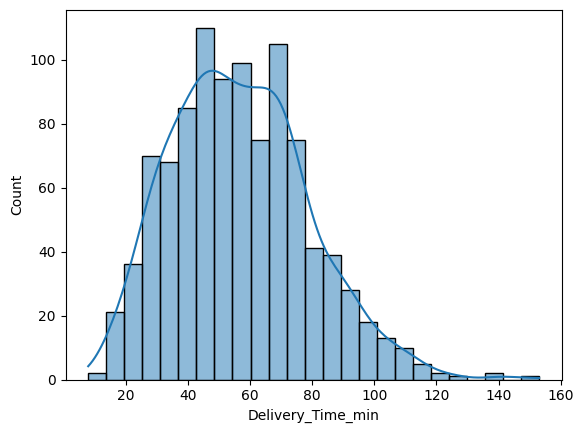

In [95]:
sns.histplot(df['Delivery_Time_min'],kde=True)
plt.show()

In [96]:
mode_Traffic_Level = df["Traffic_Level"].mode()[0] 
mode_Weather = df["Weather"].mode()[0]  
mode_Time_of_Day = df["Time_of_Day"].mode()[0]  
df.fillna({"Time_of_Day": mode_Time_of_Day,"Weather": mode_Weather,"Traffic_Level": mode_Traffic_Level}, inplace=True)

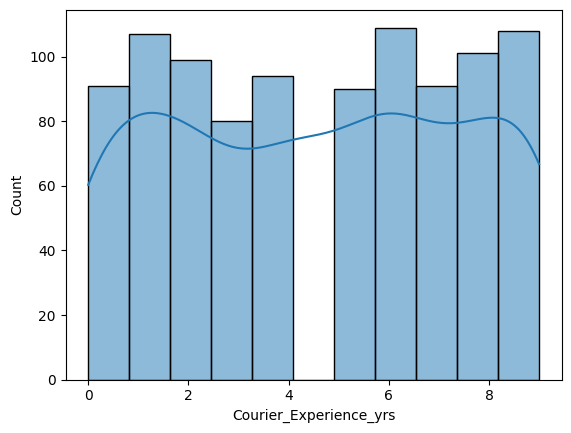

In [97]:
sns.histplot(df['Courier_Experience_yrs'],kde=True)
plt.show()

In [98]:
median= df["Courier_Experience_yrs"].median()
median

5.0

In [99]:
df.fillna({"Courier_Experience_yrs":median},inplace=True)

#### Select the numerical column

In [100]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

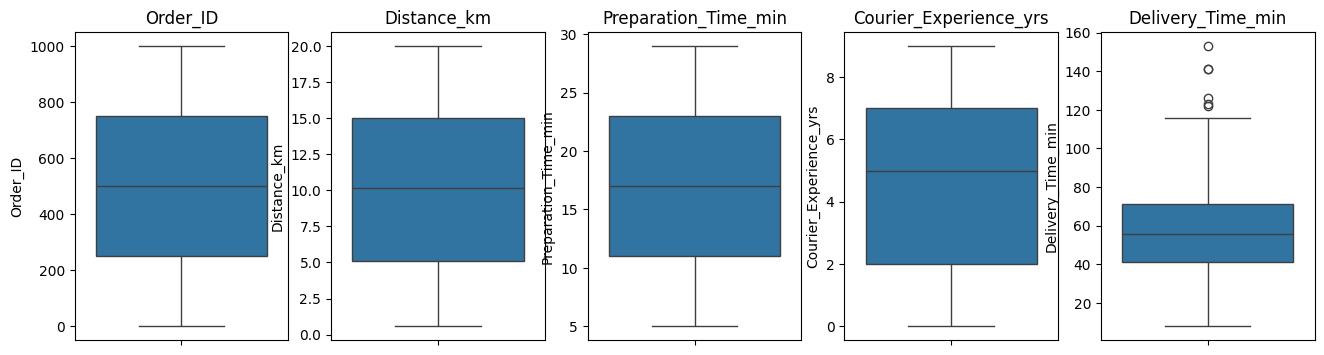

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_columns), figsize=(16, 4))

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, y=col, ax=axes[i]) 
    axes[i].set_title(col)

In [102]:
df.shape

(1000, 9)

#### Removing the outlier

In [103]:
Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Delivery_Time_min'] >= lower_bound) & (df['Delivery_Time_min'] <= upper_bound)]

In [104]:
df = df.reset_index(drop=True)

In [105]:
df.shape

(994, 9)

<Axes: ylabel='Delivery_Time_min'>

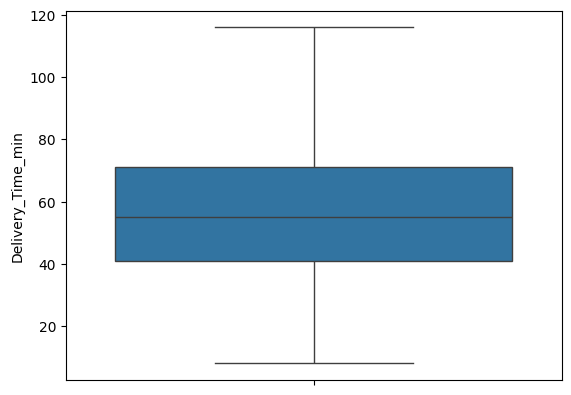

In [106]:
sns.boxplot(df['Delivery_Time_min'])

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                994 non-null    int64  
 1   Distance_km             994 non-null    float64
 2   Weather                 994 non-null    object 
 3   Traffic_Level           994 non-null    object 
 4   Time_of_Day             994 non-null    object 
 5   Vehicle_Type            994 non-null    object 
 6   Preparation_Time_min    994 non-null    int64  
 7   Courier_Experience_yrs  994 non-null    float64
 8   Delivery_Time_min       994 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.0+ KB


In [108]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

# Checking for duplicate rows

In [109]:
df[df.duplicated()]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


### Shape of the DataFrame

In [110]:
df.shape

(994, 9)

### Encode the Categorical columns

In [111]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [112]:
categorical_columns

['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

In [113]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
label_encoder = LabelEncoder()
df['Traffic_Level'] = df['Traffic_Level'].map({'Low':0,'Medium':1,'High':2})
df['Vehicle_Type'] = df['Vehicle_Type'].map({'Scooter':0,'Bike':1,'Car':2})
df['Time_of_Day'] = df['Time_of_Day'].map({'Morning':0,'Afternoon':1,'Evening':2,'Night':3})

In [114]:
df = pd.get_dummies(df, columns=['Weather'])

In [115]:
df

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,522,7.93,0,1,0,12,1.0,43,False,False,False,False,True
1,738,16.42,1,2,1,20,2.0,84,True,False,False,False,False
2,741,9.52,0,3,0,28,1.0,59,False,True,False,False,False
3,661,7.44,1,1,0,5,1.0,37,False,False,True,False,False
4,412,19.03,0,0,1,16,5.0,68,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,107,8.50,2,2,2,13,3.0,54,True,False,False,False,False
990,271,16.28,0,0,0,8,9.0,71,False,False,True,False,False
991,861,15.62,2,2,0,26,2.0,81,False,False,False,True,False
992,436,14.17,0,1,1,8,0.0,55,True,False,False,False,False


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                994 non-null    int64  
 1   Distance_km             994 non-null    float64
 2   Traffic_Level           994 non-null    int64  
 3   Time_of_Day             994 non-null    int64  
 4   Vehicle_Type            994 non-null    int64  
 5   Preparation_Time_min    994 non-null    int64  
 6   Courier_Experience_yrs  994 non-null    float64
 7   Delivery_Time_min       994 non-null    int64  
 8   Weather_Clear           994 non-null    bool   
 9   Weather_Foggy           994 non-null    bool   
 10  Weather_Rainy           994 non-null    bool   
 11  Weather_Snowy           994 non-null    bool   
 12  Weather_Windy           994 non-null    bool   
dtypes: bool(5), float64(2), int64(6)
memory usage: 67.1 KB


In [117]:
df.columns

Index(['Order_ID', 'Distance_km', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy',
       'Weather_Snowy', 'Weather_Windy'],
      dtype='object')

In [118]:
df.corr()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
Order_ID,1.000000,-0.027130,0.000763,0.012673,0.069717,-0.034963,0.012549,-0.043732,0.011659,-0.034416,0.024612,0.027825,-0.045923
Distance_km,-0.027130,1.000000,0.010175,-0.041244,0.018046,-0.013415,-0.005914,0.788343,-0.051335,-0.023860,0.028846,0.075548,-0.003697
Traffic_Level,0.000763,0.010175,1.000000,0.015530,-0.054436,-0.025992,0.041983,0.201855,-0.010900,-0.030997,0.011486,-0.027751,0.062958
Time_of_Day,0.012673,-0.041244,0.015530,1.000000,-0.027430,0.037023,0.022399,-0.001982,-0.003088,0.027182,0.027112,0.016658,-0.076846
Vehicle_Type,0.069717,0.018046,-0.054436,-0.027430,1.000000,-0.014110,-0.004160,0.030738,-0.073720,0.000415,0.009859,0.075217,0.035529
Preparation_Time_min,-0.034963,-0.013415,-0.025992,0.037023,-0.014110,1.000000,-0.027556,0.307307,0.012571,-0.015516,0.016706,0.020194,-0.048542
Courier_Experience_yrs,0.012549,-0.005914,0.041983,0.022399,-0.004160,-0.027556,1.000000,-0.086789,-0.051091,-0.054361,0.071914,0.012063,0.032637
Delivery_Time_min,-0.043732,0.788343,0.201855,-0.001982,0.030738,0.307307,-0.086789,1.000000,-0.170785,0.051202,0.066515,0.167780,-0.023017
Weather_Clear,0.011659,-0.051335,-0.010900,-0.003088,-0.073720,0.012571,-0.051091,-0.170785,1.000000,-0.340001,-0.505025,-0.328844,-0.325074
Weather_Foggy,-0.034416,-0.023860,-0.030997,0.027182,0.000415,-0.015516,-0.054361,0.051202,-0.340001,1.000000,-0.171709,-0.111807,-0.110525


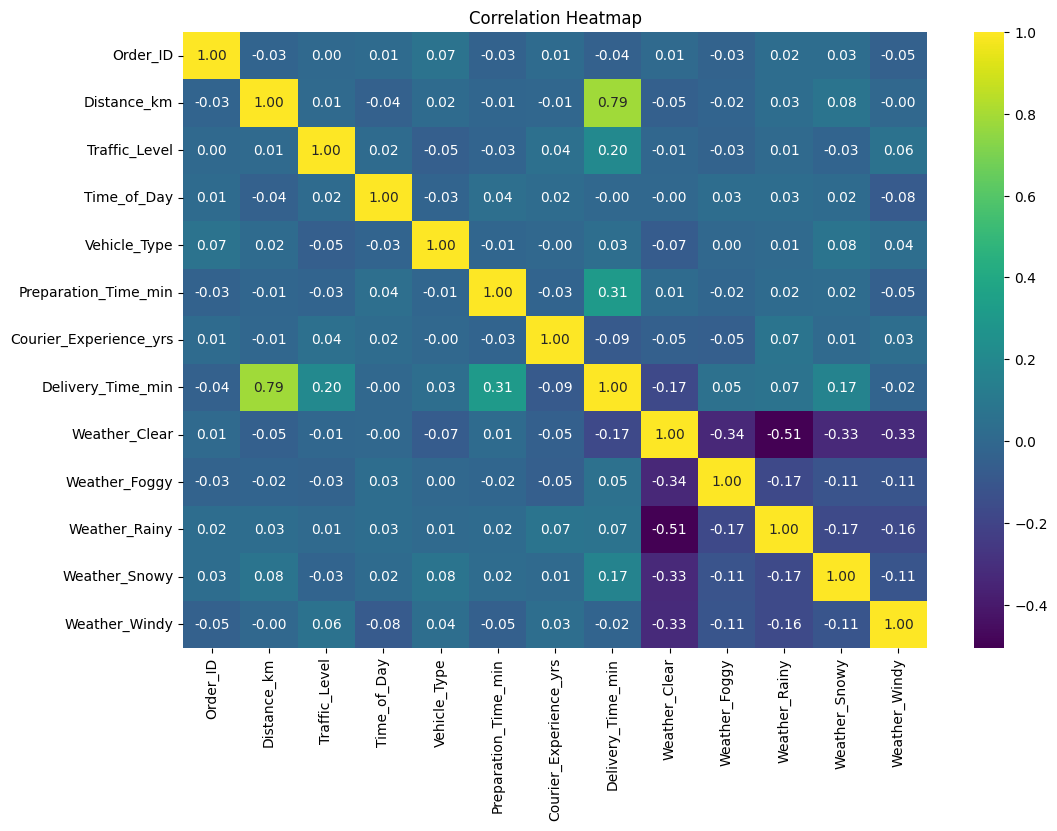

In [119]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [120]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [121]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])

In [122]:
X = df.drop(columns=['Delivery_Time_min','Order_ID'],axis=1)
y = df['Delivery_Time_min']

In [123]:
num_columns

['Order_ID',
 'Distance_km',
 'Traffic_Level',
 'Time_of_Day',
 'Vehicle_Type',
 'Preparation_Time_min',
 'Courier_Experience_yrs',
 'Delivery_Time_min']

In [124]:
X.head()

,Distance_km,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,-0.367188,-1.103612,-0.128683,-1.282155,-0.688605,-1.250681,False,False,False,False,True
1,1.127042,0.250697,0.894601,0.154668,0.422102,-0.902842,True,False,False,False,False
2,-0.087350,-1.103612,1.917884,-1.282155,1.532810,-1.250681,False,True,False,False,False
3,-0.453427,0.250697,-0.128683,-1.282155,-1.660475,-1.250681,False,False,True,False,False
4,1.586399,-1.103612,-1.151966,0.154668,-0.133251,0.140675,True,False,False,False,False


# Train Test Split

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model

In [126]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [127]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
y_pred = model.predict(X_test)

# metrics

In [128]:
mae =mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [129]:
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 0.16295031801161663
R-squared: 0.8512725646051958
Mean Absolute Error: 0.2631854445242069


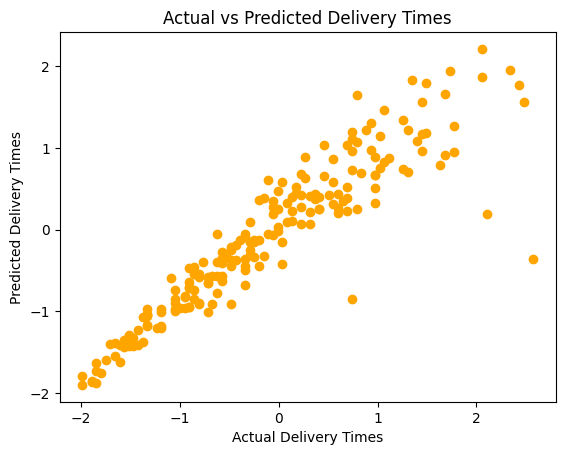

In [130]:
plt.scatter(y_test, y_pred,color='orange',marker='o')

plt.xlabel('Actual Delivery Times')
plt.ylabel('Predicted Delivery Times')
plt.title('Actual vs Predicted Delivery Times')
plt.show()